# 03 · BiLSTM Classifier: random vs pretrained (fastText) embeddings

The TF-IDF baselines in notebook 02 treat a tweet as a bag of n-grams: they ignore word order, and they know nothing about a word that never appears in the 1,810 training tweets. This notebook tests two ideas from the course that address those weaknesses:

1. **Recurrent sequence modelling (BiLSTM).** The model reads the tweet left-to-right and right-to-left, so word order and context ("si nzuri" = "not good") can affect the prediction.
2. **Pretrained word embeddings (fastText).** The fastText Kiswahili vectors (Grave et al., 2018) were trained on Common Crawl, so the model starts with useful representations even for words that are rare or absent in our training set. This targets the high OOV rate found in notebook 01.

**Architecture**

```
tweet ──► tokens ──► Embedding (300-d) ──► BiLSTM (128 per direction) ──► pooling ──► dropout ──► Linear(256→3) ──► softmax
                         │                                                   │
              random init OR fastText cc.sw.300                    max-pool OR additive attention
```

**Experiments.** Every configuration is trained with **3 random seeds** and reported as mean ± std, because notebook 02 showed that single runs on this small dataset are noisy.

| ID | Embeddings | Embedding training | Pooling | Question it answers |
|---|---|---|---|---|
| L1 | random | trained | max | Can a BiLSTM learn from 1.8k tweets alone? |
| L2 | fastText | frozen | max | Do pretrained embeddings help? |
| L3 | fastText | fine-tuned | max | Does adapting them to sentiment help further? |
| L4 | fastText | fine-tuned | attention | Does learned attention pooling beat max pooling? |
| L5 | best of the above | | | Ablation: the same model **without** class weighting |

In [1]:
# --- Setup: works both locally and in Google Colab ---
import os, sys
REPO_URL = "https://github.com/Joellate/kiswahili-sentiment-analysis.git"

if "google.colab" in sys.modules:
    if not os.path.exists("kiswahili-sentiment-analysis"):
        !git clone -q $REPO_URL
    %cd kiswahili-sentiment-analysis
    %pip install -q -r requirements.txt
else:
    # running locally from notebooks/
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir("..")

sys.path.insert(0, "src")
print("Working directory:", os.getcwd())

Working directory: C:\Users\AltTronic\kiswahili-sentiment-analysis


In [2]:
import gzip
import random
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from data import load_all, LABELS
from evaluate import aggregate_seeds, compute_metrics, log_experiment, plot_confusion, report
from preprocessing import clean_text

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SMOKE = os.environ.get("SMOKE_TEST") == "1"   # tiny run used only to check the code end-to-end
SEEDS = [13] if SMOKE else [13, 42, 2026]
MAX_LEN = 48                                  # longest tweet is 45 words
print("Device:", DEVICE, "| seeds:", SEEDS)

splits = load_all()
tokens = {s: [clean_text(t).split() for t in d.text] for s, d in splits.items()}
y = {s: d.label.values for s, d in splits.items()}

Device: cpu | seeds: [13, 42, 2026]


## 1. Vocabulary and inputs

Each tweet becomes a fixed-length sequence of word ids, padded with `0` (`<pad>`). Unknown words map to `1` (`<unk>`).

We build two vocabularies:
- **Train-only** (for random embeddings). A word that never appears in training has a random vector the model never learned, so it is mapped to `<unk>`.
- **Train + fastText-covered words** (for pretrained embeddings). A validation or test word that has a fastText vector can be kept, because its vector already carries meaning. This uses no labels, only the unlabelled text and the public vectors.

In [3]:
def build_vocab(words):
    itos = ["<pad>", "<unk>"] + sorted(words)
    return itos, {w: i for i, w in enumerate(itos)}

def encode(token_lists, stoi):
    ids = [[stoi.get(w, 1) for w in toks][:MAX_LEN] for toks in token_lists]
    return torch.tensor([row + [0] * (MAX_LEN - len(row)) for row in ids])

train_words = Counter(w for toks in tokens["train"] for w in toks)
itos_train, stoi_train = build_vocab(train_words)
X_train_vocab = {s: encode(t, stoi_train) for s, t in tokens.items()}
for s in ["validation", "test"]:
    unk = (X_train_vocab[s] == 1).sum().item() / (X_train_vocab[s] > 0).sum().item()
    print(f"{s:10s}: {unk:.1%} of tokens are <unk> with the train-only vocabulary")

validation: 19.6% of tokens are <unk> with the train-only vocabulary
test      : 20.5% of tokens are <unk> with the train-only vocabulary


## 2. fastText Kiswahili embeddings

We use `cc.sw.300.vec.gz` (Grave et al., 2018): 300-dimensional vectors trained on Common Crawl and Wikipedia. The file is about 230 MB, and we keep only the vectors for words in our data.

In [4]:
FT_URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.sw.300.vec.gz"
FT_PATH = "data/cc.sw.300.vec.gz"
if not os.path.exists(FT_PATH):
    print("Downloading fastText vectors (~230 MB)...")
    urllib.request.urlretrieve(FT_URL, FT_PATH)

all_words = {w for toks_list in tokens.values() for toks in toks_list for w in toks}
ft_vectors = {}
with gzip.open(FT_PATH, "rt", encoding="utf-8", errors="ignore") as f:
    n_ft, dim = map(int, next(f).split())
    for line in f:
        word, rest = line.split(" ", 1)
        if word in all_words:
            ft_vectors[word] = np.asarray(rest.split(), dtype="float32")
print(f"fastText vocabulary: {n_ft:,} words; {len(ft_vectors):,} of our {len(all_words):,} word types found")

# vocabulary for pretrained runs = train words + any word that has a fastText vector
itos_ft, stoi_ft = build_vocab(set(train_words) | set(ft_vectors))
X_ft_vocab = {s: encode(t, stoi_ft) for s, t in tokens.items()}

rng = np.random.default_rng(0)
ft_matrix = rng.normal(0, 0.1, (len(itos_ft), dim)).astype("float32")
ft_matrix[0] = 0
for w, i in stoi_ft.items():
    if w in ft_vectors:
        ft_matrix[i] = ft_vectors[w]

cov = pd.DataFrame({
    "train word types covered": [np.mean([w in ft_vectors for w in train_words])],
    "test tokens covered": [np.mean([w in ft_vectors for toks in tokens['test'] for w in toks])],
    "test tokens <unk> (train vocab)": [(X_train_vocab['test'] == 1).sum().item() / (X_train_vocab['test'] > 0).sum().item()],
    "test tokens <unk> (train+fastText vocab)": [(X_ft_vocab['test'] == 1).sum().item() / (X_ft_vocab['test'] > 0).sum().item()],
}).T.rename(columns={0: "rate"})
cov.style.format("{:.1%}")

fastText vocabulary: 387,963 words; 7,704 of our 12,456 word types found


,rate
train word types covered,65.9%
test tokens covered,86.4%
test tokens (train vocab),20.5%
test tokens (train+fastText vocab),9.1%


**Reading this:** fastText vectors shrink the share of test tokens the model has never seen. This is the mechanism by which pretrained embeddings could help. Words that are still uncovered are typically misspellings, slang, names, or merged words (e.g. *jionikaribu* = *jioni karibu*).

## 3. Model

Implementation notes:
- **`pack_padded_sequence`.** The LSTM skips padding entirely. Without it, the backward direction would begin by reading a long run of `<pad>` tokens.
- **Max pooling** keeps, for each hidden dimension, the strongest signal anywhere in the tweet.
- **Additive attention** (Bahdanau et al., 2015) learns a weight for each word and takes the weighted sum. The weights also show which words the model relied on.

In [5]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=300, hidden=128, n_classes=3, dropout=0.5,
                 pooling="max", pretrained=None, freeze_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        if pretrained is not None:
            self.embedding.weight.data.copy_(torch.as_tensor(pretrained))
        self.embedding.weight.requires_grad = not freeze_embeddings
        self.emb_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.pooling = pooling
        if pooling == "attention":
            self.attention = nn.Sequential(nn.Linear(2 * hidden, hidden), nn.Tanh(), nn.Linear(hidden, 1, bias=False))
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(2 * hidden, n_classes)

    def forward(self, x, return_attention=False):
        mask = x != 0                                            # (batch, seq) True on real tokens
        lengths = mask.sum(1).clamp(min=1).cpu()
        emb = self.emb_dropout(self.embedding(x))                # (batch, seq, emb_dim)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        h, _ = self.lstm(packed)
        h, _ = nn.utils.rnn.pad_packed_sequence(h, batch_first=True, total_length=x.size(1))  # (batch, seq, 2*hidden)

        if self.pooling == "max":
            pooled = h.masked_fill(~mask.unsqueeze(-1), -1e4).max(dim=1).values
            weights = None
        else:
            scores = self.attention(h).squeeze(-1).masked_fill(~mask, -1e4)   # (batch, seq)
            weights = torch.softmax(scores, dim=1)
            pooled = (weights.unsqueeze(-1) * h).sum(dim=1)
        logits = self.out(self.dropout(pooled))
        return (logits, weights) if return_attention else logits

m = BiLSTMClassifier(len(itos_ft), pretrained=ft_matrix)
print(m)
print(f"Trainable parameters (fine-tuned embeddings): {sum(p.numel() for p in m.parameters() if p.requires_grad):,}")

BiLSTMClassifier(
  (embedding): Embedding(10710, 300, padding_idx=0)
  (emb_dropout): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(300, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (out): Linear(in_features=256, out_features=3, bias=True)
)
Trainable parameters (fine-tuned embeddings): 3,654,091


## 4. Training loop

- **Loss:** cross-entropy with **class weights** `n / (3 · n_class)`. A mistake on the rare *negative* class costs about 3× more than one on *neutral*, which notebook 02 showed is essential.
- **Optimiser:** Adam (lr = 1e-3), batch size 32, gradient clipping at 1.0.
- **Early stopping:** we keep the epoch with the best **validation macro-F1** and stop after 5 epochs without improvement (at most 30 epochs).

In [6]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

counts = np.bincount(y["train"], minlength=len(LABELS))
CLASS_WEIGHTS = torch.tensor(len(y["train"]) / (len(LABELS) * counts), dtype=torch.float32)
print("Class weights:", dict(zip(LABELS, CLASS_WEIGHTS.numpy().round(2))))

BASE_CFG = dict(emb_dim=300, hidden=128, dropout=0.5, lr=1e-3, batch_size=32,
                epochs=2 if SMOKE else 30, patience=5, pooling="max",
                embeddings="random", freeze_embeddings=False, class_weight=True)


@torch.no_grad()
def predict_proba(model, X):
    model.eval()
    return torch.cat([torch.softmax(model(X[i:i + 256].to(DEVICE)), -1).cpu() for i in range(0, len(X), 256)]).numpy()


def train_one(cfg, seed):
    set_seed(seed)
    pretrained = cfg["embeddings"] == "fasttext"
    X = X_ft_vocab if pretrained else X_train_vocab
    model = BiLSTMClassifier(len(itos_ft if pretrained else itos_train), cfg["emb_dim"], cfg["hidden"],
                             dropout=cfg["dropout"], pooling=cfg["pooling"],
                             pretrained=ft_matrix if pretrained else None,
                             freeze_embeddings=cfg["freeze_embeddings"]).to(DEVICE)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=cfg["lr"])
    loss_fn = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE) if cfg["class_weight"] else None)
    loader = DataLoader(TensorDataset(X["train"], torch.tensor(y["train"])), batch_size=cfg["batch_size"],
                        shuffle=True, generator=torch.Generator().manual_seed(seed))

    best_f1, best_state, bad, history = -1.0, None, 0, []
    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += loss.item() * len(yb)
        val_f1 = compute_metrics(y["validation"], predict_proba(model, X["validation"]).argmax(1))["macro_f1"]
        history.append({"epoch": epoch, "train_loss": total / len(y["train"]), "val_macro_f1": val_f1})
        if val_f1 > best_f1:
            best_f1, bad = val_f1, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= cfg["patience"]:
                break
    model.load_state_dict(best_state)
    return model, X, pd.DataFrame(history)


def run_experiment(name, **overrides):
    """Train with every seed, log mean metrics, return the run with the best validation score."""
    cfg = {**BASE_CFG, **overrides}
    val_runs, test_runs, runs = [], [], []
    for seed in SEEDS:
        model, X, hist = train_one(cfg, seed)
        val_m = compute_metrics(y["validation"], predict_proba(model, X["validation"]).argmax(1))
        test_proba = predict_proba(model, X["test"])
        test_m = compute_metrics(y["test"], test_proba.argmax(1))
        val_runs.append(val_m); test_runs.append(test_m)
        runs.append(dict(seed=seed, model=model, X=X, history=hist, val_f1=val_m["macro_f1"], test_proba=test_proba))
        print(f"  {name} | seed {seed}: {len(hist)} epochs, val macro-F1 {val_m['macro_f1']:.3f}, test macro-F1 {test_m['macro_f1']:.3f}")
    val_agg, test_agg = aggregate_seeds(val_runs), aggregate_seeds(test_runs)
    if not SMOKE:
        log_experiment(name, "validation", val_agg, cfg)
        log_experiment(name, "test", test_agg, cfg)
    print(f"{name}: val {val_agg['macro_f1']:.3f} ± {val_agg['macro_f1_std']:.3f} | "
          f"test {test_agg['macro_f1']:.3f} ± {test_agg['macro_f1_std']:.3f}\n")
    best = max(runs, key=lambda r: r["val_f1"])
    best.update(cfg=cfg, val_mean=val_agg["macro_f1"])
    return best

Class weights: {'positive': np.float32(1.1), 'neutral': np.float32(0.56), 'negative': np.float32(3.16)}


## 5. Experiments

In [7]:
results = {}
results["L1"] = run_experiment("L1 BiLSTM random emb", embeddings="random")
results["L2"] = run_experiment("L2 BiLSTM fastText frozen", embeddings="fasttext", freeze_embeddings=True)
results["L3"] = run_experiment("L3 BiLSTM fastText fine-tuned", embeddings="fasttext")
results["L4"] = run_experiment("L4 BiLSTM fastText fine-tuned + attention", embeddings="fasttext", pooling="attention")

  L1 BiLSTM random emb | seed 13: 15 epochs, val macro-F1 0.416, test macro-F1 0.451


  L1 BiLSTM random emb | seed 42: 28 epochs, val macro-F1 0.418, test macro-F1 0.444


  L1 BiLSTM random emb | seed 2026: 11 epochs, val macro-F1 0.400, test macro-F1 0.405
L1 BiLSTM random emb: val 0.411 ± 0.008 | test 0.433 ± 0.021



  L2 BiLSTM fastText frozen | seed 13: 16 epochs, val macro-F1 0.434, test macro-F1 0.461


  L2 BiLSTM fastText frozen | seed 42: 11 epochs, val macro-F1 0.389, test macro-F1 0.422


...

  L3 BiLSTM fastText fine-tuned | seed 2026: 9 epochs, val macro-F1 0.444, test macro-F1 0.456


L3 BiLSTM fastText fine-tuned: val 0.444 ± 0.001 | test 0.446 ± 0.008



  L4 BiLSTM fastText fine-tuned + attention | seed 13: 9 epochs, val macro-F1 0.433, test macro-F1 0.460


  L4 BiLSTM fastText fine-tuned + attention | seed 42: 9 epochs, val macro-F1 0.428, test macro-F1 0.441


  L4 BiLSTM fastText fine-tuned + attention | seed 2026: 9 epochs, val macro-F1 0.443, test macro-F1 0.463
L4 BiLSTM fastText fine-tuned + attention: val 0.435 ± 0.006 | test 0.455 ± 0.010



In [8]:
best_id = max(["L1", "L2", "L3", "L4"], key=lambda k: results[k]["val_mean"])
print("Best configuration on validation:", best_id)
no_cw = {k: v for k, v in results[best_id]["cfg"].items() if k in BASE_CFG}
no_cw["class_weight"] = False
results["L5"] = run_experiment(f"L5 {best_id} without class weights", **no_cw)

Best configuration on validation: L3


  L5 L3 without class weights | seed 13: 17 epochs, val macro-F1 0.430, test macro-F1 0.409


  L5 L3 without class weights | seed 42: 14 epochs, val macro-F1 0.421, test macro-F1 0.417


  L5 L3 without class weights | seed 2026: 18 epochs, val macro-F1 0.457, test macro-F1 0.451
L5 L3 without class weights: val 0.436 ± 0.015 | test 0.426 ± 0.018



## 6. Results

In [9]:
log = pd.read_csv("results/experiments.csv")
cols = ["macro_f1", "macro_f1_std", "accuracy", "f1_positive", "f1_neutral", "f1_negative"]
lstm = log[log.experiment.str.startswith("L")]
table = lstm[lstm.split == "test"].set_index("experiment")[cols].join(
    lstm[lstm.split == "validation"].set_index("experiment")[["macro_f1"]].rename(columns={"macro_f1": "val_macro_f1"}))
best_baseline = log[(log.split == "test") & log.experiment.str.match(r"B[1-5]")].sort_values("macro_f1").iloc[-1]
print(f"Reference, best TF-IDF baseline on test: {best_baseline.experiment} = {best_baseline.macro_f1:.3f}")
table.round(3)

Reference, best TF-IDF baseline on test: B1a word TF-IDF + LogReg (raw text) = 0.486


,macro_f1,macro_f1_std,accuracy,f1_positive,f1_neutral,f1_negative,val_macro_f1
experiment,,,,,,,
L1 BiLSTM random emb,0.433,0.020,0.522,0.444,0.614,0.242,0.412
L2 BiLSTM fastText frozen,0.444,0.016,0.524,0.403,0.628,0.300,0.416
L3 BiLSTM fastText fine-tuned,0.446,0.008,0.545,0.408,0.652,0.277,0.444
L4 BiLSTM fastText fine-tuned + attention,0.455,0.010,0.536,0.418,0.639,0.308,0.435
L5 L3 without class weights,0.426,0.018,0.537,0.411,0.647,0.220,0.436


### Learning curves (best configuration, best seed)

If the training loss keeps falling while validation F1 stays flat or drops, the model is overfitting. Early stopping is what protects against this.

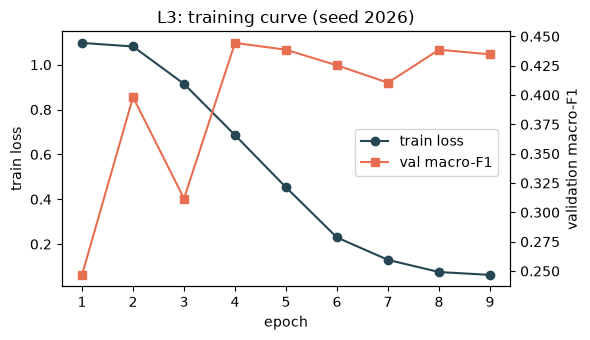

In [10]:
best = results[best_id]
h = best["history"]
fig, ax1 = plt.subplots(figsize=(6, 3.5))
ax1.plot(h.epoch, h.train_loss, "o-", color="#264653", label="train loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("train loss")
ax2 = ax1.twinx()
ax2.plot(h.epoch, h.val_macro_f1, "s-", color="#e76f51", label="val macro-F1")
ax2.set_ylabel("validation macro-F1")
fig.legend(loc="center right", bbox_to_anchor=(0.85, 0.55))
ax1.set_title(f"{best_id}: training curve (seed {best['seed']})")
fig.tight_layout(); fig.savefig("results/figures/bilstm_learning_curve.png", dpi=150); plt.show()

### Confusion matrix and per-class report (best configuration, best seed, test set)

              precision    recall  f1-score   support

    positive      0.416     0.531     0.467       224
     neutral      0.677     0.547     0.605       444
    negative      0.262     0.338     0.295        80

    accuracy                          0.520       748
   macro avg      0.452     0.472     0.456       748
weighted avg      0.554     0.520     0.531       748



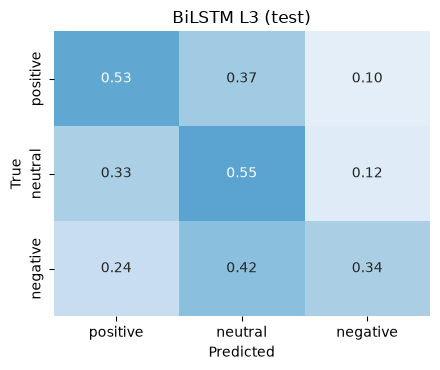

In [11]:
test_pred = best["test_proba"].argmax(1)
print(report(y["test"], test_pred))
_ = plot_confusion(y["test"], test_pred, f"BiLSTM {best_id} (test)", save_as="cm_bilstm.png")

## 7. What does attention look at? (L4)

For a few test tweets we print each word with its attention weight. Larger weights mean the word contributed more to the pooled representation. Attention weights are only a rough guide to what the model "used" (Jain & Wallace, 2019), but they help spot obvious failure modes, for example attending to names or numbers rather than to sentiment words.

In [12]:
att = results["L4"]
att_model, X_att = att["model"], att["X"]
att_model.eval()
idx = splits["test"].groupby("label").head(2).index[:6]
with torch.no_grad():
    logits, weights = att_model(X_att["test"][idx].to(DEVICE), return_attention=True)
for row, i in enumerate(idx):
    toks = tokens["test"][i][:MAX_LEN]
    w = weights[row, :len(toks)].cpu().numpy()
    top = ", ".join(f"{t} ({v:.2f})" for t, v in sorted(zip(toks, w), key=lambda x: -x[1])[:4])
    print(f"TRUE {LABELS[y['test'][i]]:8s} PRED {LABELS[logits[row].argmax().item()]:8s} | {splits['test'].text[i][:90]}")
    print(f"    top attention: {top}\n")

TRUE positive PRED neutral  |    Ulitaka kujua siasa hzi za democrazy nawaomba musome kitabu kinachoitwa The Prince by M
    top attention: the (0.14), prince (0.13), machiavelli (0.13), ndio (0.12)

TRUE neutral  PRED neutral  | Chama chenye sera kali za mrengo wa kulia ambacho kimefanya kampeni kwa kutumia jukwaa la 
    top attention: uchaguzi (0.08), nyingi (0.08), katika (0.07), kura (0.07)

TRUE negative PRED negative |    Mwaka mmoja wa Rais Magufuli na mkwamo wa elimu yetu
    top attention: mwaka (0.34), mmoja (0.19), wa (0.10), rais (0.08)

TRUE neutral  PRED neutral  |    Umeondoka kimya kimya mzee wangu Sijapenda Time ingeruhusi ningetumia Usafiri Kutoka kw
    top attention: hawa (0.17), kwa (0.13), kimya (0.09), kutoka (0.09)

TRUE positive PRED neutral  | Watu wengine hawatakupenda hata ufanye nini na watu wengine hawataacha kukupenda hata ufan
    top attention: watu (0.19), nini (0.14), na (0.12), wengine (0.11)

TRUE negative PRED negative | Watu 12 wamefariki na weng

## 8. Save the best BiLSTM and its test predictions

In [13]:
os.makedirs("models", exist_ok=True)
torch.save({"state_dict": best["model"].state_dict(), "cfg": best["cfg"],
            "itos": itos_ft if best["cfg"]["embeddings"] == "fasttext" else itos_train},
           "models/bilstm_best.pt")
preds = splits["test"][["text", "label_name"]].assign(
    pred=[LABELS[i] for i in test_pred],
    **{f"p_{lab}": best["test_proba"][:, i].round(4) for i, lab in enumerate(LABELS)})
preds.to_csv("results/predictions_bilstm.csv", index=False)
preds.head()

,text,label_name,pred,p_positive,p_neutral,p_negative
0,Ulitaka kujua siasa hzi za democrazy nawaom...,positive,positive,0.5264,0.4348,0.0388
1,Chama chenye sera kali za mrengo wa kulia amba...,neutral,negative,0.0799,0.2939,0.6262
2,Mwaka mmoja wa Rais Magufuli na mkwamo wa e...,negative,negative,0.2541,0.1856,0.5603
3,Umeondoka kimya kimya mzee wangu Sijapenda ...,neutral,neutral,0.3996,0.5676,0.0327
4,Watu wengine hawatakupenda hata ufanye nini na...,positive,neutral,0.3675,0.5948,0.0377


## Takeaways

Test macro-F1, mean ± std over 3 seeds:

| | Test macro-F1 | F1 negative |
|---|---|---|
| L1 random embeddings | 0.433 ± 0.021 | 0.24 |
| L2 fastText, frozen | 0.444 ± 0.016 | 0.30 |
| L3 fastText, fine-tuned | 0.446 ± 0.008 | 0.28 |
| L4 fastText, fine-tuned + attention | 0.455 ± 0.010 | 0.31 |
| L5 = L3 without class weights | 0.426 ± 0.018 | 0.22 |
| *Best TF-IDF baseline (B1 / B3)* | *0.47–0.48* | *0.30–0.31* |

1. **The BiLSTM does not beat the TF-IDF baseline.** This is the main result of this notebook. A more complex model is not automatically better, and here there are clear reasons:
   - **Too little data for the number of parameters.** The BiLSTM has 3.65M trainable parameters (3.2M of them in the embedding table) and only 1,810 training tweets. In the learning curve above, validation F1 peaks at epoch 4 while training loss keeps falling to about 0.06. The model memorises the training set, which is classic overfitting, and early stopping is what rescues it. A linear TF-IDF model has far fewer effective degrees of freedom and a strong bias that suits small data.
   - **Sentiment in these short tweets is largely lexical.** Words such as *amefariki* and *asante* carry most of the signal. Word order, which is the BiLSTM's advantage, rarely changes the label. Emojis and punctuation, which often mark negation or emphasis, were already removed from the data.
2. **fastText helps, but only a little.** It adds about +0.01–0.02 macro-F1 (L1 → L2/L3) and **halves the variance across seeds** (std 0.021 → 0.008), so training is more stable. The gain is small because coverage is limited. Only 66% of the training word types have a fastText vector, since Common Crawl Kiswahili is formal web text while tweets contain slang, merged words (*jionikaribu*) and misspellings. Using the fastText vocabulary still cuts test `<unk>` tokens from 20.5% to 9.1%.
3. **Frozen and fine-tuned embeddings perform about the same** (0.444 vs 0.446), well within one standard deviation. With this little data, updating 300-dimensional embeddings gives the model no reliable extra signal.
4. **Attention pooling is the best BiLSTM on test (0.455) but not on validation.** The difference is within noise. The attention weights in section 7 mostly fall on topic or function words (*watu*, *mwaka*, *the*, numbers), not on sentiment words. This is consistent with Jain & Wallace (2019): attention weights are not a faithful explanation of the model.
5. **Class weighting helps, but less than for TF-IDF.** Removing it costs 0.02 macro-F1 and 0.06 negative-class F1 (L3 → L5). For TF-IDF the drop was 0.08 and 0.20. Early stopping on *macro*-F1 already pushes the BiLSTM to keep some recall on the rare class.

**Implication for notebook 04:** the bottleneck is not the architecture but **how much Kiswahili the model has seen**. Pretrained Transformers bring knowledge from millions of sentences and use subword tokenisation (no `<unk>`). The next experiment tests whether that overcomes the 1.8k-tweet limit.

In [14]:
# On Colab: download the updated results folder, then copy it into your local repo and commit
if "google.colab" in sys.modules:
    !zip -qr results_03.zip results
    from google.colab import files
    files.download("results_03.zip")